In [1]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

p = Path("data/futures")
parquet_files = sorted(p.glob("*.parquet"))
parquet_files

[PosixPath('data/futures/6E.parquet'),
 PosixPath('data/futures/6J.parquet'),
 PosixPath('data/futures/CL.parquet'),
 PosixPath('data/futures/ES.parquet'),
 PosixPath('data/futures/GC.parquet'),
 PosixPath('data/futures/NG.parquet'),
 PosixPath('data/futures/NQ.parquet'),
 PosixPath('data/futures/SI.parquet'),
 PosixPath('data/futures/YM.parquet'),
 PosixPath('data/futures/ZB.parquet'),
 PosixPath('data/futures/ZN.parquet')]

In [2]:
dfs = []
for f in parquet_files:
    df = pd.read_parquet(f)

    # flatten multi index
    df.columns = [c[0] for c in df.columns]

    df["ticker"] = f.stem
    
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    
    dfs.append(df)

df = pd.concat(dfs, ignore_index=True, sort=False)

In [3]:
earliest_per_ticker = df.groupby("ticker")["timestamp"].min().reset_index().sort_values("timestamp")
earliest_per_ticker

,ticker,timestamp
2,CL,2000-08-23
4,GC,2000-08-30
5,NG,2000-08-30
7,SI,2000-08-30
0,6E,2000-09-12
1,6J,2000-09-13
3,ES,2000-09-18
6,NQ,2000-09-18
9,ZB,2000-09-21
10,ZN,2000-09-21


In [4]:
# remove rows with timestamps before 2002-04-05
import datetime
cutoff = datetime.datetime(2002, 4, 5)
df = df[df["timestamp"] >= cutoff].reset_index(drop=True)
df

,timestamp,close,high,low,open,volume,ticker
0,2002-04-05,0.876700,0.878900,0.874800,0.875500,0,6E
1,2002-04-08,0.871600,0.876900,0.871100,0.876700,0,6E
2,2002-04-09,0.878100,0.878500,0.871200,0.872100,0,6E
3,2002-04-10,0.878000,0.880000,0.876400,0.878500,0,6E
4,2002-04-11,0.880700,0.882300,0.876800,0.878000,0,6E
...,...,...,...,...,...,...,...
65679,2025-12-12,112.343750,112.593750,112.281250,112.593750,761,ZN
65680,2025-12-15,112.453125,112.609375,112.453125,112.609375,2017,ZN
65681,2025-12-16,112.687500,112.687500,112.203125,112.562500,1340,ZN
65682,2025-12-17,112.671875,112.703125,112.421875,112.687500,1340,ZN


In [5]:
def get_agnostic_tokens(df, n_bins=10):
    # 1. Calculate True Range and ATR
    high_low = df["high"] - df["low"]
    high_pc = (df["high"] - df["close"].shift(1)).abs()
    low_pc = (df["low"] - df["close"].shift(1)).abs()

    
    tr = pd.concat([high_low, high_pc, low_pc], axis=1).max(axis=1)
    atr = tr.rolling(14).mean()
    
    # conviction and explosion (ATR may be NaN for the first rows)
    conviction = (df["close"] - df["open"]) / atr
    explosion = (df["high"] - df["low"]) / atr

    df["non_zero_volume"] = df["volume"] + 1e-12

    # relative volume
    rel_volume = df["non_zero_volume"] / (df["non_zero_volume"].rolling(50).mean())

    # categorize returns into 5 classes using conviction = (close-open)/atr
    # classes (ints): 0 = up_big, 1 = up, 2 = neutral, 3 = down, 4 = down_big
    conv = conviction

    # initialize as NaN so positions with NaN ATR/conv stay missing
    ret = pd.Series(np.nan, index=df.index)

    # thresholds are in multiples of ATR (tunable)
    ret[conv >= 2.0] = 0
    ret[(conv >= 0.5) & (conv < 2.0)] = 1
    ret[conv.abs() < 0.5] = 2
    ret[(conv <= -0.5) & (conv > -2.0)] = 3
    ret[conv <= -2.0] = 4

    # shift labels so they represent the next period's outcome
    ret = ret.shift(-1)

    # use pandas nullable integer dtype to preserve missing values
    ret_codes = ret.astype("Int64")

    # quantile bins — keep index alignment (don't dropna here)
    c_codes = pd.qcut(conviction, q=n_bins, labels=False, duplicates='drop')
    e_codes = pd.qcut(explosion, q=n_bins, labels=False, duplicates='drop')
    rv_codes = pd.qcut(rel_volume, q=n_bins, labels=False, duplicates='drop')

    # any position missing in one should be considered missing in all -> create combined mask
    mask = (c_codes == -1) | (e_codes == -1) | (rv_codes == -1)
    c_codes[mask] = None
    e_codes[mask] = None
    rv_codes[mask] = None

    c_codes = c_codes.dropna()
    e_codes = e_codes.dropna()
    rv_codes = rv_codes.dropna()

    # debug counts (should match)
    # print((c_codes == -1).sum(), (e_codes == -1).sum(), (rv_codes == -1).sum())

    # convert to strings and join into a single token
    c_s = c_codes.astype(int).astype(str)
    e_s = e_codes.astype(int).astype(str)
    rv_s = rv_codes.astype(int).astype(str)

    tokens = c_s + "_" + e_s + "_" + rv_s
    return tokens, ret_codes

number_of_classes = 5
feature_bins = 10
# compute tokens per ticker and store back into the main df
df['token'] = None
for _, g in df.groupby('ticker', sort=False):
    df.loc[g.index, 'token'], df.loc[g.index, "ret"] = get_agnostic_tokens(g, n_bins=feature_bins)

df.dropna()

,timestamp,close,high,low,open,volume,ticker,token,ret
49,2002-06-13,0.941800,0.947200,0.939500,0.943700,0,6E,3_4_5,2
50,2002-06-14,0.945400,0.952600,0.941700,0.943000,0,6E,6_7_5,2
51,2002-06-17,0.942900,0.946600,0.941200,0.944800,0,6E,3_1_5,1
52,2002-06-18,0.947400,0.948300,0.939800,0.940600,0,6E,9_5_5,1
53,2002-06-19,0.952700,0.954200,0.948000,0.948000,0,6E,8_2_5,1
...,...,...,...,...,...,...,...,...,...
65678,2025-12-11,112.609375,112.812500,112.578125,112.578125,937,ZN,5_1_0,3
65679,2025-12-12,112.343750,112.593750,112.281250,112.593750,761,ZN,1_4_0,2
65680,2025-12-15,112.453125,112.609375,112.453125,112.609375,2017,ZN,2_0_0,2
65681,2025-12-16,112.687500,112.687500,112.203125,112.562500,1340,ZN,7_8_0,2


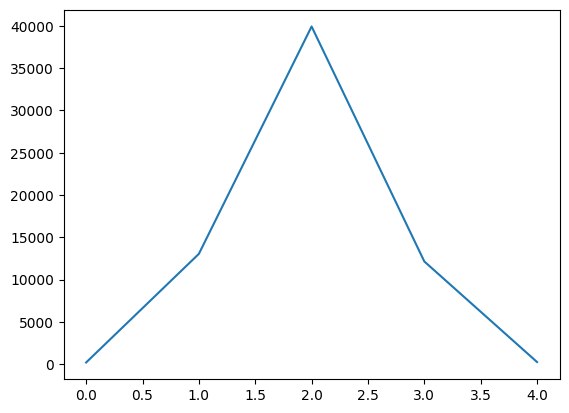

In [6]:
plt.plot(df["ret"].value_counts().sort_index())

In [7]:
bigger_df = pd.read_parquet("data/ibm_data.parquet").rename(columns={"symbol": "ticker"})
bigger_df["token"], bigger_df["ret"] = get_agnostic_tokens(bigger_df)
bigger_df = bigger_df.dropna()
# df = bigger_df

In [8]:
# align all tickers to a common timestamp index and rebuild a compact (T_common, N, 1) integer array
# pivot tokens so each column is a ticker and index are timestamps
token_pivot = df.pivot(index="timestamp", columns="ticker", values="token").sort_index()
ret_pivot = df.pivot(index="timestamp", columns="ticker", values="ret").sort_index()


# keep only timestamps present for every ticker
common_mask = token_pivot.notna().all(axis=1) & ret_pivot.notna().all(axis=1)
T_common = int(common_mask.sum())
print("T_common:", T_common)

# restrict pivot to the common timestamps (ensures every column has the same index)
token_pivot = token_pivot.loc[common_mask]
ret_pivot = ret_pivot.loc[common_mask]

# tickers in consistent order
tickers = token_pivot.columns.tolist()
N = len(tickers)
print("N (tickers):", N, "tickers:", tickers)

# split token strings into three component classes (conviction, explosion, rel_volume)
c_pivot = token_pivot.applymap(lambda s: int(s.split("_")[0]))
e_pivot = token_pivot.applymap(lambda s: int(s.split("_")[1]))
rv_pivot = token_pivot.applymap(lambda s: int(s.split("_")[2]))

# as numpy arrays (T_common, N)
c_arr = c_pivot.values.astype(np.int32)
e_arr = e_pivot.values.astype(np.int32)
rv_arr = rv_pivot.values.astype(np.int32)

# combined array with last dim = 3 (conviction, explosion, rel_volume)
class_arr = np.stack([c_arr, e_arr, rv_arr], axis=-1)

# show result (replace with any further processing you need)
c_pivot.head()

T_common: 5887
N (tickers): 11 tickers: ['6E', '6J', 'CL', 'ES', 'GC', 'NG', 'NQ', 'SI', 'YM', 'ZB', 'ZN']


/var/folders/60/wj5t6qgs4mg17szk59gn23300000gn/T/ipykernel_25694/2377145250.py:22: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  c_pivot = token_pivot.applymap(lambda s: int(s.split("_")[0]))
/var/folders/60/wj5t6qgs4mg17szk59gn23300000gn/T/ipykernel_25694/2377145250.py:23: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  e_pivot = token_pivot.applymap(lambda s: int(s.split("_")[1]))
/var/folders/60/wj5t6qgs4mg17szk59gn23300000gn/T/ipykernel_25694/2377145250.py:24: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  rv_pivot = token_pivot.applymap(lambda s: int(s.split("_")[2]))


ticker,6E,6J,CL,ES,GC,NG,NQ,SI,YM,ZB,ZN
timestamp,,,,,,,,,,,
2002-06-14,6,9,8,3,1,9,5,3,3,9,8
2002-06-17,3,2,4,9,3,3,9,3,9,0,1
2002-06-18,9,4,1,7,8,4,7,3,8,4,1
2002-06-19,8,8,4,0,3,5,0,3,2,7,6
2002-06-20,8,7,5,1,7,0,1,6,1,0,0


In [9]:
ret_pivot

ticker,6E,6J,CL,ES,GC,NG,NQ,SI,YM,ZB,ZN
timestamp,,,,,,,,,,,
2002-06-14,2,2,2,1,2,2,1,2,1,3,3
2002-06-17,1,2,3,2,1,2,2,2,1,2,3
2002-06-18,1,1,2,3,2,2,3,2,2,2,2
2002-06-19,1,2,2,3,2,3,3,1,3,3,3
2002-06-20,1,0,2,2,2,2,2,2,3,2,2
...,...,...,...,...,...,...,...,...,...,...,...
2025-12-11,2,2,2,3,2,2,3,3,3,3,3
2025-12-12,2,1,2,2,2,3,2,1,2,2,2
2025-12-15,2,2,3,2,1,3,2,2,3,1,2


In [10]:
df = df.dropna()
vocab = df["token"].unique().tolist()
vocab_len = len(vocab)

T = len(token_pivot)
N = len(df["ticker"].unique())

T, N

(5887, 11)

In [11]:
# build integer mapping once (vocab is defined in the notebook)
# token_to_id = {tok: i for i, tok in enumerate(range(vocab)}

# allocate array (T,N,1) with integer dtype
all_sequences = np.zeros((T, N, 3), dtype=np.int32)
all_targets = np.zeros((T, N))

for idx, sym in enumerate(tickers):
    seq_ids = np.array([c_pivot[sym].astype(np.int32).values,
                       e_pivot[sym].astype(np.int32).values,
                        rv_pivot[sym].astype(np.int32).values])

    # print(seq_ids.T.shape)
    # assert seq_ids.shape[0] == T
    all_sequences[:, idx] = seq_ids.T
    all_targets[:, idx] = ret_pivot[sym].astype(np.int32)

all_sequences.shape, all_sequences.dtype

((5887, 11, 3), dtype('int32'))

In [12]:
all_targets

array([[2., 2., 2., ..., 1., 3., 3.],
       [1., 2., 3., ..., 1., 2., 3.],
       [1., 1., 2., ..., 2., 2., 2.],
       ...,
       [2., 2., 3., ..., 3., 1., 2.],
       [2., 3., 1., ..., 2., 2., 2.],
       [2., 2., 2., ..., 2., 2., 2.]], shape=(5887, 11))

In [13]:
# build dataset

# build dataloader

# instantiate model

# train model

# inspect

In [14]:
from model.my_dataset import MyDataset
from torch.utils.data import DataLoader
from model.model_definition import SimpleTransformer
from model.training import train_loop
import torch

In [15]:
np.unique(all_targets)

array([0., 1., 2., 3., 4.])

In [16]:
class_freqs = np.unique(all_targets, return_counts=True)[1]
class_freqs, number_of_classes

(array([  188, 12866, 39493, 11967,   243]), 5)

In [ ]:
SEQ_LEN = 64
BATCH_SIZE = 1

train_dataset = MyDataset(all_sequences[:int(T*0.8)], all_targets[:int(T*0.8)], SEQ_LEN)
tmp = []
[tmp.append(train_dataset[i]) for i in range(30)]
val_dataset = MyDataset(all_sequences[int(T*0.8):], all_targets[int(T*0.8):], SEQ_LEN)
tmp2 = []
[tmp2.append(val_dataset[i]) for i in range(30, 40)]


train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE)



# pass frequencies to the model (as a list)
model = SimpleTransformer(feature_bins, SEQ_LEN, number_of_classes, symbol_count=N, output_class_freq=class_freqs, attention_layers=2, hidden_dim=32)

res = train_loop(model, train_dataloader, val_dataloader, 100, 1e-4, 1e-5, torch.device("cpu"), "checkpoint", 10)

Training on device: cpu
Trainable parameters: 28997
Training samples: 4646, Validation samples: 1115
--------------------------------------------------------------------------------


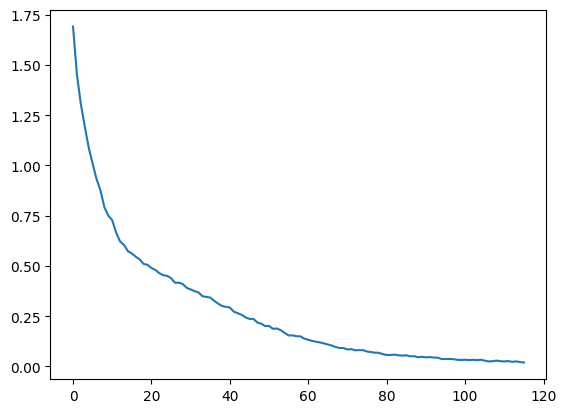

In [ ]:
plt.plot(res["history"]["train_loss"])

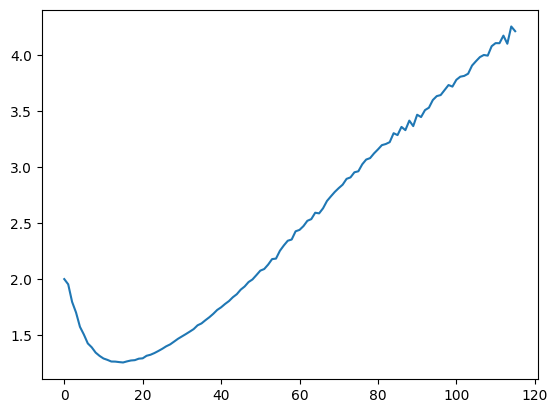

In [ ]:
plt.plot(res["history"]["val_loss"])

In [ ]:
model.eval()
with torch.no_grad():
    for x_batch, y_batch in val_dataloader:
        preds, _ = model(x_batch)
        # print(preds)
        break
preds

tensor([[[[0.0023, 0.2395, 0.2872, 0.4667, 0.0043]],

         [[0.0070, 0.1314, 0.5470, 0.3125, 0.0021]],

         [[0.0037, 0.2041, 0.5374, 0.2513, 0.0034]],

         [[0.0149, 0.1367, 0.7072, 0.1388, 0.0025]],

         [[0.0029, 0.2194, 0.3344, 0.4372, 0.0061]],

         [[0.0027, 0.3256, 0.3149, 0.3509, 0.0059]],

         [[0.0062, 0.2891, 0.4611, 0.2333, 0.0103]],

         [[0.0131, 0.2988, 0.4919, 0.1939, 0.0023]],

         [[0.0033, 0.1785, 0.1865, 0.6136, 0.0181]],

         [[0.0184, 0.0501, 0.2272, 0.6977, 0.0066]],

         [[0.0255, 0.1265, 0.6225, 0.2180, 0.0076]],

         [[0.0046, 0.3428, 0.3966, 0.2518, 0.0041]],

         [[0.0049, 0.1001, 0.4586, 0.4311, 0.0054]],

         [[0.0102, 0.3820, 0.2452, 0.3584, 0.0043]],

         [[0.0096, 0.1777, 0.2284, 0.5717, 0.0126]],

         [[0.0029, 0.7625, 0.1233, 0.1024, 0.0090]],

         [[0.0013, 0.2897, 0.4864, 0.2171, 0.0055]],

         [[0.0139, 0.2199, 0.6742, 0.0885, 0.0035]],

         [[0.0194, 0.0613, 0

In [ ]:
preds = preds.squeeze(0)

In [ ]:
preds = preds.view(preds.shape[0]*preds.shape[1], preds.shape[2])

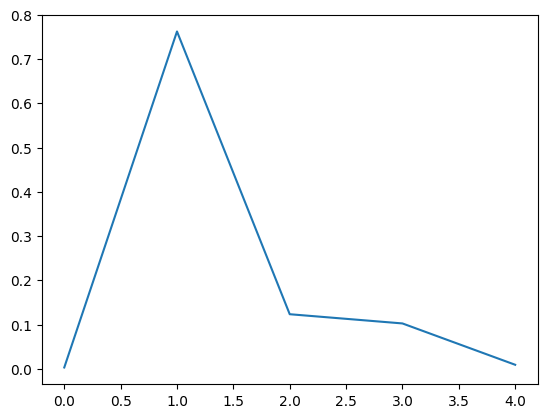

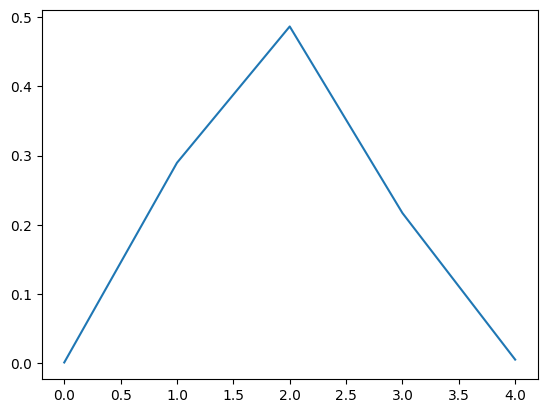

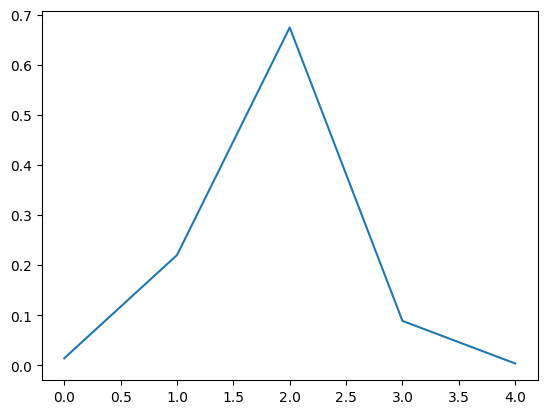

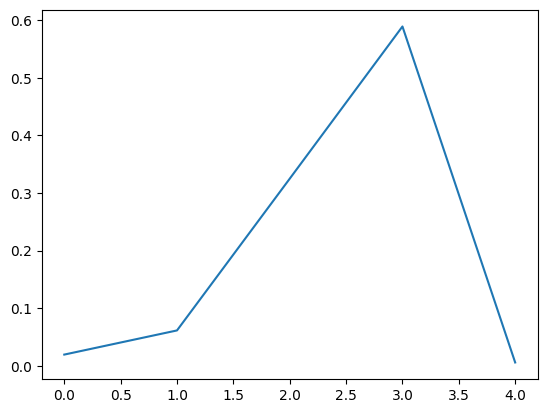

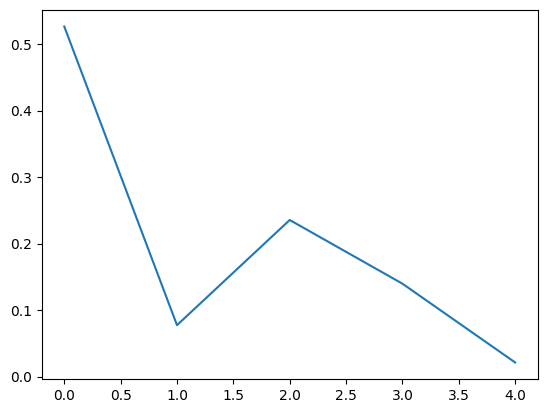

In [ ]:
for i in range(15, 20):
    plt.plot(preds[i])
    plt.show()